## Setup - Import library and function

In [1]:
import sys
from pathlib import Path

# Add root project's folder (parent of notebooks/) into sys.path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_dataset
from src.split_save_data import split_train_val_test, save_train_val_test
from src.feature_engineer import run_feature_engineering
from src.mutual_information import select_top_features_by_mi
from src.select_by_dt import select_by_dt
import src.config as config

## Original

In [2]:
df = load_dataset(config.CLEVELAND_CSV_PATH)
train, val, test = split_train_val_test(df)


<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB
None


In [3]:
save_train_val_test(train,val,test,config.RAW_DIR)

Đã lưu 240 dòng train (79.5%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw\train.csv
Đã lưu 31 dòng val (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw\val.csv
Đã lưu 31 dòng test (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw\test.csv


## Feature Engineer

In [4]:
X_train, y_train = train.drop(columns=[config.TARGET_COL]), train[config.TARGET_COL]
X_val, y_val = val.drop(columns=[config.TARGET_COL]), val[config.TARGET_COL]
X_test, y_test = test.drop(columns=[config.TARGET_COL]), test[config.TARGET_COL]

X_fe_train, X_fe_val, X_fe_test, pipeline = run_feature_engineering(
    X_train, X_val, X_test, y_train
)


Number of features after feature engineering: 36


## Selecting feature base on Mutual Information

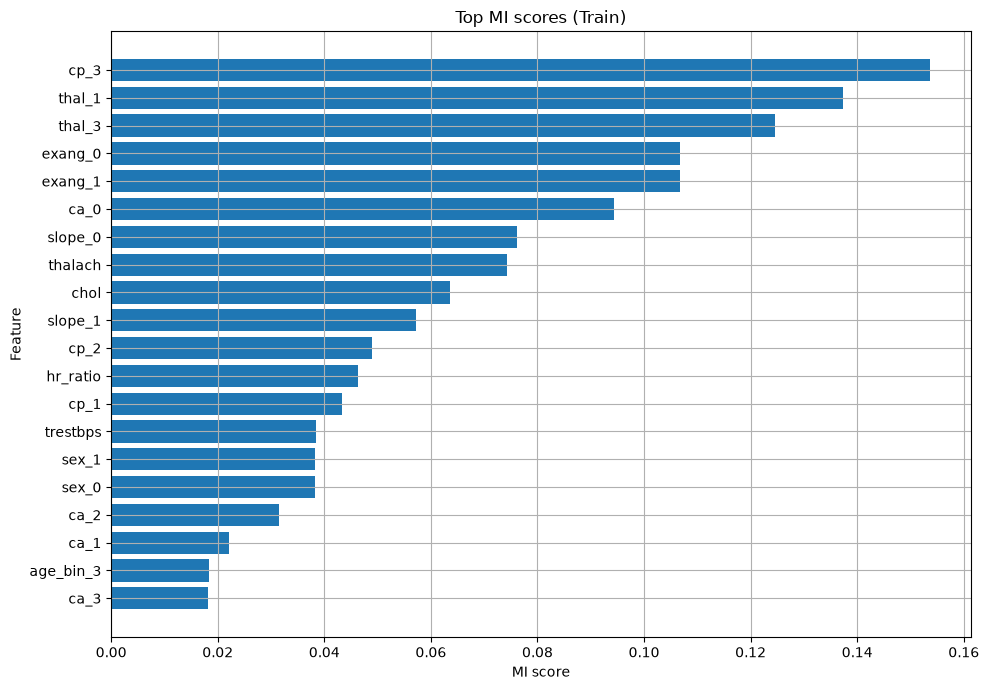

In [5]:
k = len(config.COLS)
topk_cols, scores = select_top_features_by_mi(
    pipeline, config.CATEGORICAL_COLS + ["age_bin"],
    X_fe_train, y_train,
    K=k
)

N = min(20, len(scores))      
top_for_plot = scores.head(N).iloc[::-1]  

plt.figure(figsize=(10, max(6, 0.35 * N)))
plt.barh(top_for_plot.index, top_for_plot.values) 
plt.title("Top MI scores (Train)")
plt.xlabel("MI score")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
importance, select_cols = select_by_dt(X_train, y_train, k=10, prefix="dt")

X_train_sel = X_train[select_cols]
X_val_sel = X_val[select_cols]
X_test_sel = X_test[select_cols]

dt_train = pd.concat([X_train_sel, y_train], axis=1)
dt_val = pd.concat([X_val_sel, y_val], axis = 1)
dt_test = pd.concat([X_test_sel, y_test], axis = 1)

save_train_val_test(dt_train,dt_val,dt_test,config.RAW_REDUCED_DIR)


Top 10 đặc trưng (dt): ['cp', 'thal', 'ca', 'oldpeak', 'age', 'sex', 'chol', 'restecg', 'thalach', 'slope']
Đã lưu 240 dòng train (79.5%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw_reduced\train.csv
Đã lưu 31 dòng val (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw_reduced\val.csv
Đã lưu 31 dòng test (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\raw_reduced\test.csv


In [7]:
Xk_fe_train = X_fe_train[topk_cols]
Xk_fe_val = X_fe_val[topk_cols]
Xk_fe_test = X_fe_test[topk_cols]

df_fe_train = pd.concat(
    [Xk_fe_train.reset_index(drop=True), 
     y_train.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)
df_fe_val = pd.concat(
    [Xk_fe_val.reset_index(drop=True), 
     y_val.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)
df_fe_test = pd.concat(
    [Xk_fe_test.reset_index(drop=True), 
     y_test.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)

save_train_val_test(df_fe_train,df_fe_val,df_fe_test,config.ENGINEERED_DIR)


Đã lưu 240 dòng train (79.5%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered\train.csv
Đã lưu 31 dòng val (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered\val.csv
Đã lưu 31 dòng test (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered\test.csv


In [8]:
fe_importance, fe_select_cols = select_by_dt(Xk_fe_train, y_train, k=10, prefix="dt")

X_dtfe_train = Xk_fe_train[fe_select_cols]
X_dtfe_val = Xk_fe_val[fe_select_cols]
X_dtfe_test = Xk_fe_test[fe_select_cols]

df_dtfe_train = pd.concat(
    [X_dtfe_train.reset_index(drop=True), 
     y_train.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)
df_dtfe_val = pd.concat(
    [X_dtfe_val.reset_index(drop=True), 
     y_val.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)
df_dtfe_test = pd.concat(
    [X_dtfe_test.reset_index(drop=True), 
     y_test.reset_index(drop=True).rename(config.TARGET_COL)],
    axis=1
)

save_train_val_test(df_dtfe_train,df_dtfe_val,df_dtfe_test,config.ENGINEERED_REDUCED_DIR)

Top 10 đặc trưng (dt): ['cp_3', 'hr_ratio', 'chol', 'thalach', 'ca_0', 'thal_1', 'thal_3', 'slope_0', 'exang_1', 'trestbps']
Đã lưu 240 dòng train (79.5%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered_reduced\train.csv
Đã lưu 31 dòng val (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered_reduced\val.csv
Đã lưu 31 dòng test (10.3%) vào: D:\HCMUT\AIO\Project\heart-disease-diagnosis\data\engineered_reduced\test.csv


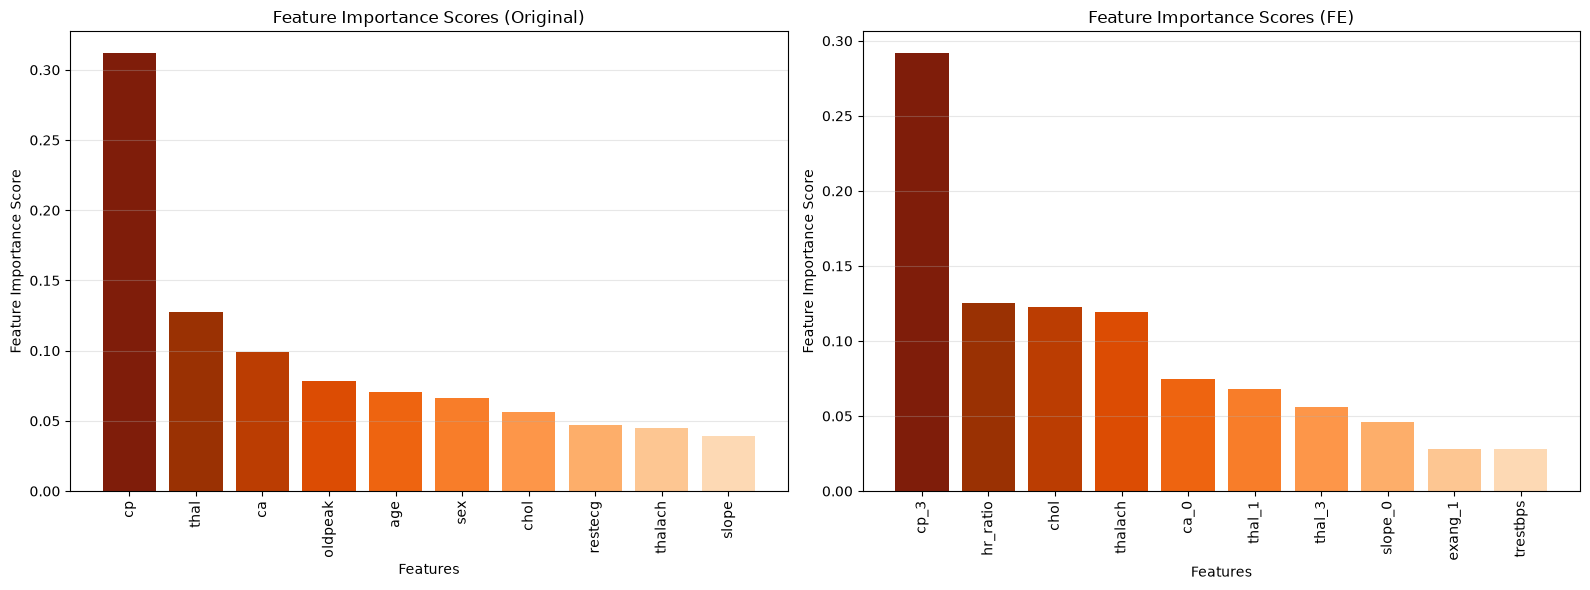

In [10]:
import matplotlib.pyplot as plt

def plot_feature_importance(importance, select_cols, title, ax=None):
    imp_series = pd.Series(importance, index=select_cols).sort_values(ascending=False)

    n = len(imp_series)
    cmap = plt.colormaps["Oranges_r"]          # <-- thay cho plt.cm.get_cmap
    colors = [cmap(i / max(n - 1, 1) * 0.8) for i in range(n)]
    colors[0] = "#7f1d0a"

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(imp_series.index, imp_series.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel("Features")
    ax.set_ylabel("Feature Importance Score")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.3)

    return ax


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_feature_importance(importance, select_cols,
                         "Feature Importance Scores (Original)", ax=axes[0])
plot_feature_importance(fe_importance, fe_select_cols,
                         "Feature Importance Scores (FE)", ax=axes[1])

plt.tight_layout()
plt.show()